In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [25]:
# Download the Online Retail dataset

import requests
import zipfile
import io

url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"

response = requests.get(url)

print("Download status:", response.status_code)

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    print("Files in dataset:")
    print(z.namelist())

    excel_file = z.namelist()[0]
    z.extract(excel_file, "/content")

df2 = pd.read_excel("/content/" + excel_file)

print("\nDataset loaded successfully!")
print("Shape:", df2.shape)

display(df2.head())

Download status: 200
Files in dataset:
['Online Retail.xlsx']

Dataset loaded successfully!
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [26]:
# Basic dataset inspection

print("Columns:")
print(df2.columns.tolist())

print("\nDataset information:")
df2.info()

print("\nFirst 5 rows:")
display(df2.head())

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [27]:
# Check missing values

print("Missing values:")
display(df2.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:", df2.duplicated().sum())

Missing values:


,Missing Values
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0



Duplicate rows: 5268


In [28]:
# Remove rows without CustomerID
df2 = df2.dropna(subset=["CustomerID"])

# Remove cancelled transactions
df2 = df2[
    ~df2["InvoiceNo"].astype(str).str.startswith("C")
]

# Remove invalid quantities and prices
df2 = df2[
    (df2["Quantity"] > 0) &
    (df2["UnitPrice"] > 0)
]

# Create total transaction value
df2["TotalPrice"] = df2["Quantity"] * df2["UnitPrice"]

# Convert date
df2["InvoiceDate"] = pd.to_datetime(df2["InvoiceDate"])

print("Cleaned dataset shape:", df2.shape)

display(df2.head())

Cleaned dataset shape: (397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [29]:
# Set the reference date as one day after the last transaction

reference_date = df2["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Latest transaction date:", df2["InvoiceDate"].max())
print("Reference date:", reference_date)

Latest transaction date: 2011-12-09 12:50:00
Reference date: 2011-12-10 12:50:00


In [30]:
# Calculate Recency, Frequency and Monetary values

rfm = df2.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

print("RFM table created successfully!")

display(rfm.head())

RFM table created successfully!


,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [31]:
# Descriptive statistics of RFM variables

display(
    rfm[["Recency", "Frequency", "Monetary"]].describe()
)

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


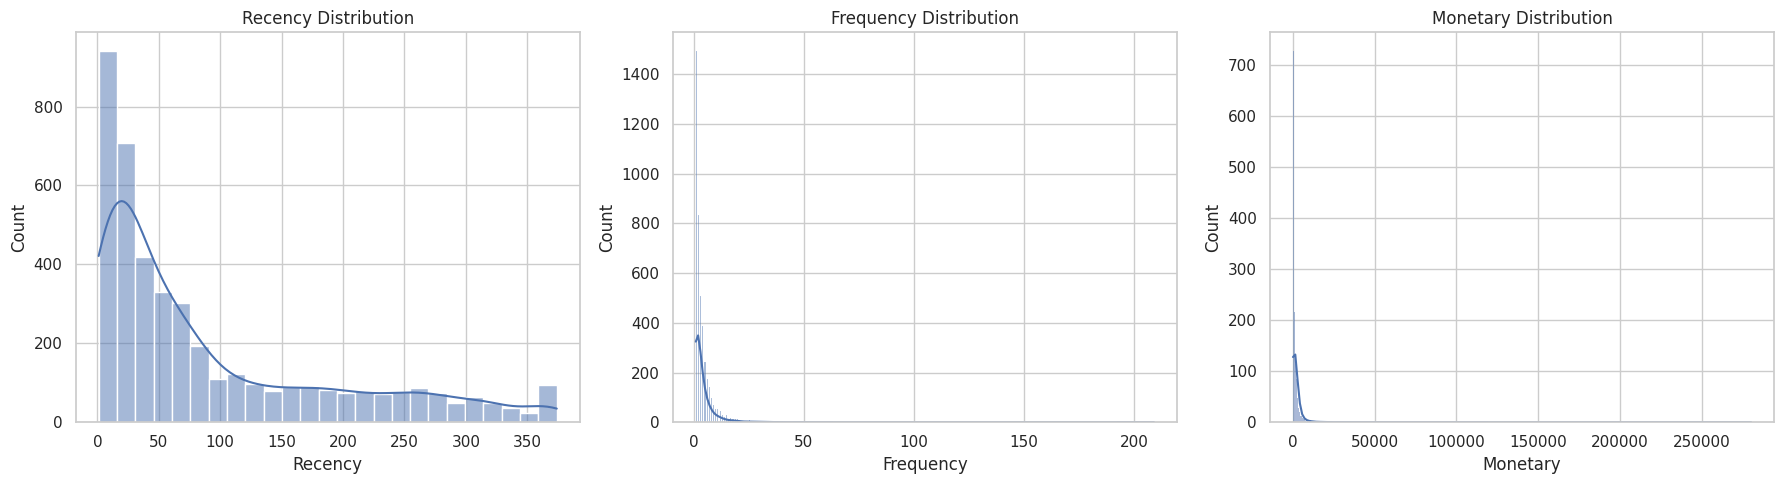

In [32]:
# Distribution of RFM variables

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], kde=True, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm["Frequency"], kde=True, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm["Monetary"], kde=True, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

In [33]:
# Check skewness of RFM variables

skewness = rfm[
    ["Recency", "Frequency", "Monetary"]
].skew()

print("Skewness:")
display(skewness.to_frame("Skewness"))

Skewness:


,Skewness
Recency,1.246048
Frequency,12.067031
Monetary,19.324953


In [34]:
# Log transformation to reduce skewness

rfm_log = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

rfm_log = np.log1p(rfm_log)

print("Log transformation completed.")

display(rfm_log.head())

Log transformation completed.


,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


In [35]:
# Standardize RFM variables

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=["Recency", "Frequency", "Monetary"]
)

print("Standardization completed!")

display(rfm_scaled.head())

Standardization completed!


,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.706225
1,-2.038734,1.074425,1.411843
2,0.373104,0.386304,0.716489
3,-0.623086,-0.955214,0.698739
4,1.424558,-0.955214,-0.618962


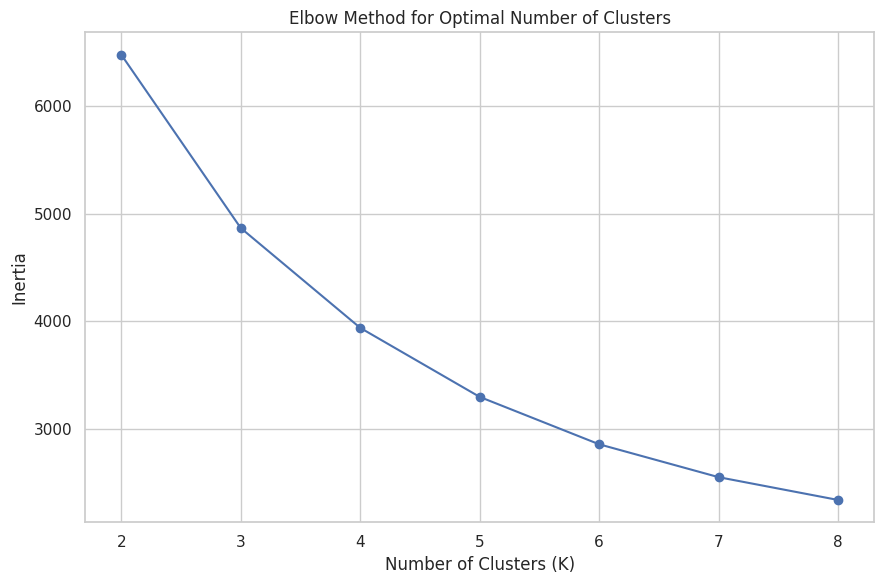

In [36]:
# Elbow method to identify a suitable number of clusters

inertia = []

K = range(2, 9)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(9, 6))

plt.plot(K, inertia, marker="o")

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.xticks(K)
plt.tight_layout()
plt.show()

In [37]:
# Apply K-Means clustering

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed!")

display(rfm.head())

K-Means clustering completed!


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,2
1,12347.0,2,7,4310.00,1
2,12348.0,75,4,1797.24,2
3,12349.0,19,1,1757.55,0
4,12350.0,310,1,334.40,3


Customers in each cluster:


,Number of Customers
Cluster,
0,837
1,716
2,1173
3,1612


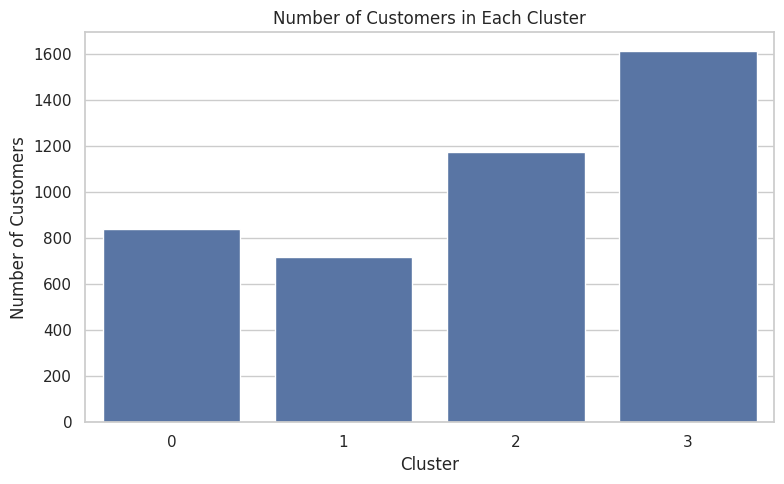

In [38]:
# Number of customers in each cluster

cluster_counts = rfm["Cluster"].value_counts().sort_index()

print("Customers in each cluster:")
display(cluster_counts.to_frame("Number of Customers"))

plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [39]:
# Compare RFM metrics across customer clusters

cluster_summary = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean")
).round(2)

display(cluster_summary)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,837,18.12,2.15,551.82
1,716,12.13,13.71,8074.27
2,1173,71.08,4.08,1802.83
3,1612,182.50,1.32,343.45


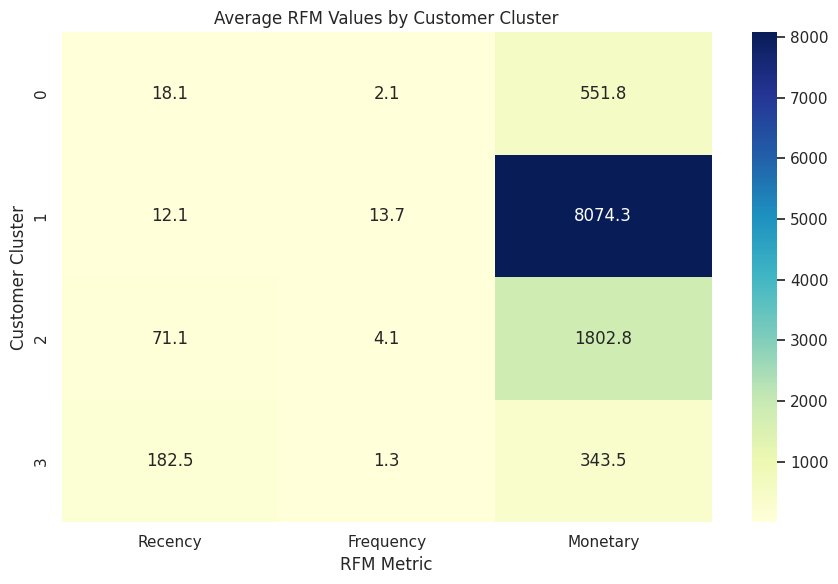

In [40]:
# Heatmap of average RFM values by cluster

cluster_rfm = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

plt.figure(figsize=(9, 6))

sns.heatmap(
    cluster_rfm,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Average RFM Values by Customer Cluster")
plt.xlabel("RFM Metric")
plt.ylabel("Customer Cluster")

plt.tight_layout()
plt.show()

In [41]:
# PCA for 2D visualization

pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

pca_df = pd.DataFrame(
    rfm_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = rfm["Cluster"].values

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

display(pca_df.head())

Explained variance ratio:
[0.75102042 0.18759201]


,PC1,PC2,Cluster
0,0.872658,2.686758,2
1,2.550260,-0.804427,1
2,0.475142,0.746121,2
3,0.145832,-0.460480,0
4,-1.688990,0.676555,3


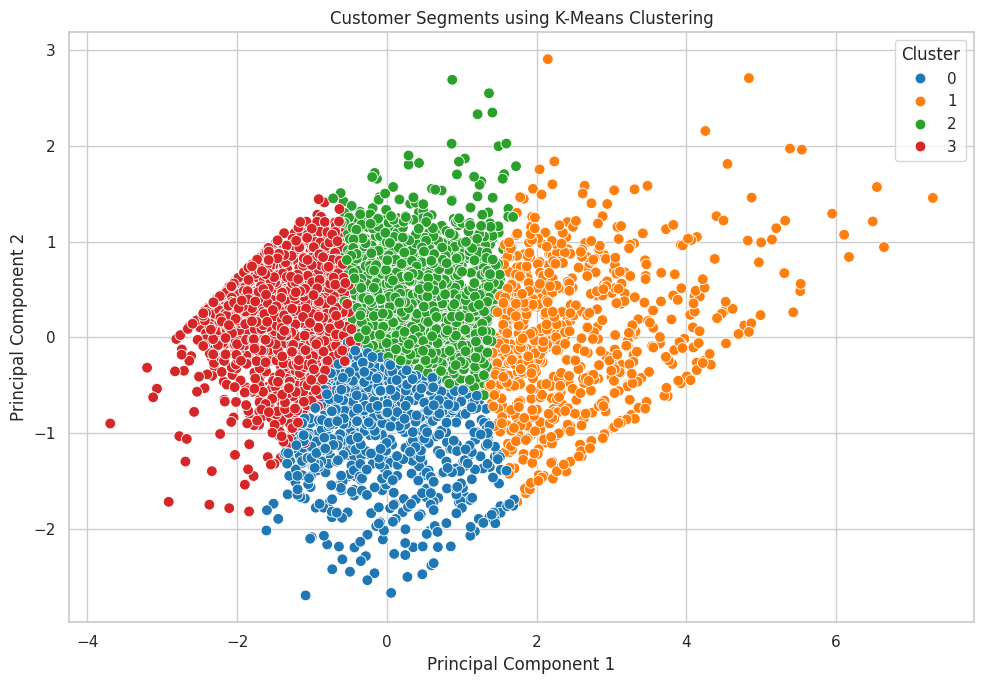

In [42]:
# Visualize customer clusters using PCA

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=60
)

plt.title("Customer Segments using K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

In [43]:
# Create standardized cluster profile

profile = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

print("Cluster Profile:")
display(profile.round(2))

Cluster Profile:


,Recency,Frequency,Monetary
Cluster,,,
0,18.12,2.15,551.82
1,12.13,13.71,8074.27
2,71.08,4.08,1802.83
3,182.50,1.32,343.45


In [44]:
# Create descriptive customer segment labels

def assign_segment(row):
    if (
        row["Recency"] <= rfm["Recency"].median()
        and row["Frequency"] >= rfm["Frequency"].median()
        and row["Monetary"] >= rfm["Monetary"].median()
    ):
        return "High-Value Customers"

    elif (
        row["Recency"] <= rfm["Recency"].median()
        and row["Frequency"] >= rfm["Frequency"].median()
    ):
        return "Loyal Customers"

    elif row["Recency"] > rfm["Recency"].median():
        return "At-Risk Customers"

    else:
        return "Occasional Customers"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

display(
    rfm[
        ["CustomerID", "Recency", "Frequency",
         "Monetary", "Cluster", "Segment"]
    ].head(10)
)

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346.0,326,1,77183.60,2,At-Risk Customers
1,12347.0,2,7,4310.00,1,High-Value Customers
2,12348.0,75,4,1797.24,2,At-Risk Customers
3,12349.0,19,1,1757.55,0,Occasional Customers
4,12350.0,310,1,334.40,3,At-Risk Customers
5,12352.0,36,8,2506.04,2,High-Value Customers
6,12353.0,204,1,89.00,3,At-Risk Customers
7,12354.0,232,1,1079.40,3,At-Risk Customers
8,12355.0,214,1,459.40,3,At-Risk Customers
9,12356.0,23,3,2811.43,2,High-Value Customers


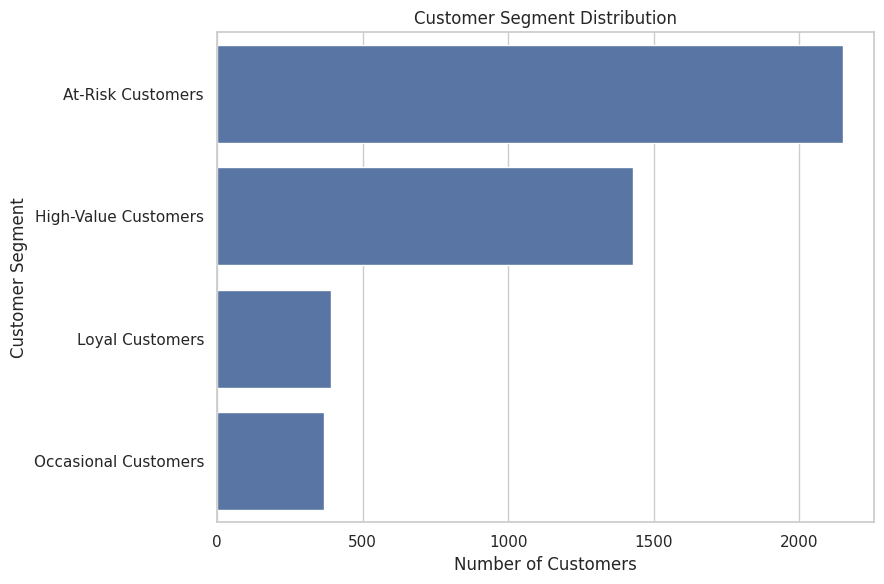

,Customers
Segment,
At-Risk Customers,2150
High-Value Customers,1429
Loyal Customers,392
Occasional Customers,367


In [45]:
# Customer segment distribution

segment_counts = rfm["Segment"].value_counts()

plt.figure(figsize=(9, 6))

sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index
)

plt.title("Customer Segment Distribution")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

display(segment_counts.to_frame("Customers"))

In [46]:
# Final customer segment summary

segment_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Average_Recency=("Recency", "mean"),
    Average_Frequency=("Frequency", "mean"),
    Average_Monetary=("Monetary", "mean")
).round(2)

display(segment_summary)

,Customers,Average_Recency,Average_Frequency,Average_Monetary
Segment,,,,
At-Risk Customers,2150,166.33,2.13,840.97
High-Value Customers,1429,17.51,8.81,4763.06
Loyal Customers,392,22.36,2.55,429.99
Occasional Customers,367,27.32,1.00,349.77


# Business Recommendations

### High-Value Customers
These customers demonstrate relatively strong purchasing activity and monetary contribution. The business can focus on retention programs, personalized offers and loyalty benefits.

### Loyal Customers
These customers purchase repeatedly and can be encouraged to increase their spending through cross-selling, product recommendations and loyalty programs.

### At-Risk Customers
These customers show relatively higher recency values, indicating that they have not purchased recently. Re-engagement campaigns, reminders and targeted offers can be considered.

### Occasional Customers
These customers show less frequent purchasing behaviour. The business can use introductory offers, personalized recommendations and targeted promotions to encourage repeat purchases.

### Overall Recommendation
Customer segmentation allows marketing resources to be allocated according to customer behaviour rather than treating all customers identically. RFM metrics and clustering can therefore support more targeted customer relationship strategies.

# Final Conclusion

This customer segmentation analysis used RFM analysis and K-Means clustering to identify groups of customers with different purchasing behaviours.

Recency measured how recently customers purchased, Frequency measured how often they purchased, and Monetary measured their overall spending. These variables were transformed and standardized before applying K-Means clustering.

The resulting customer groups were visualized using PCA and examined using cluster-level RFM statistics. The analysis provides a structured way to understand customer behaviour and can support targeted marketing, customer retention and personalized business strategies.